In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"
pd.set_option('display.max_columns', None)

In [2]:
df_flightdata = pd.read_csv("modified_flight_data.csv")

In [3]:
df_flightdata

,FlightDate,Year,Quarter,Month,DayofMonth,DayOfWeek,Airline,Origin,OriginCityName,OriginState,Dest,DestCityName,DestState,Cancelled,Diverted,CRSDepTime,DepTime,DepDelay,CRSArrTime,ArrTime,ArrDelay,DepDel15,ArrDel15,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,TaxiOut,TaxiIn,DepStatus
0,2020-09-01,2020,3,9,1,2,Comair Inc.,PHL,"Philadelphia, PA",PA,DAY,"Dayton, OH",OH,False,False,1905,1858.0,-7.0,2056,2034.0,-22.0,0.0,0.0,76.0,111.0,96.0,477.0,16.0,4.0,Early
1,2020-09-02,2020,3,9,2,3,Comair Inc.,PHL,"Philadelphia, PA",PA,DAY,"Dayton, OH",OH,False,False,1905,1858.0,-7.0,2056,2027.0,-29.0,0.0,0.0,68.0,111.0,89.0,477.0,16.0,5.0,Early
2,2020-09-03,2020,3,9,3,4,Comair Inc.,PHL,"Philadelphia, PA",PA,DAY,"Dayton, OH",OH,False,False,1905,1855.0,-10.0,2056,2122.0,26.0,0.0,1.0,77.0,111.0,147.0,477.0,65.0,5.0,Early
3,2020-09-04,2020,3,9,4,5,Comair Inc.,PHL,"Philadelphia, PA",PA,DAY,"Dayton, OH",OH,False,False,1905,1857.0,-8.0,2056,2027.0,-29.0,0.0,0.0,73.0,111.0,90.0,477.0,13.0,4.0,Early
4,2020-09-05,2020,3,9,5,6,Comair Inc.,PHL,"Philadelphia, PA",PA,DAY,"Dayton, OH",OH,False,False,1905,1856.0,-9.0,2056,2026.0,-30.0,0.0,0.0,72.0,111.0,90.0,477.0,14.0,4.0,Early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15412581,2022-03-31,2022,1,3,31,4,Republic Airlines,MSY,"New Orleans, LA",LA,EWR,"Newark, NJ",NJ,False,True,1949,2014.0,25.0,2354,234.0,NaN,1.0,NaN,NaN,185.0,NaN,1167.0,17.0,32.0,Delayed
15412582,2022-03-17,2022,1,3,17,4,Republic Airlines,CLT,"Charlotte, NC",NC,EWR,"Newark, NJ",NJ,True,False,1733,1817.0,44.0,1942,NaN,NaN,1.0,NaN,NaN,129.0,NaN,529.0,NaN,NaN,Delayed
15412583,2022-03-08,2022,1,3,8,2,Republic Airlines,ALB,"Albany, NY",NY,ORD,"Chicago, IL",IL,False,False,1700,2318.0,378.0,1838,59.0,381.0,1.0,1.0,135.0,158.0,161.0,723.0,19.0,7.0,Severely Delayed
15412584,2022-03-25,2022,1,3,25,5,Republic Airlines,EWR,"Newark, NJ",NJ,PIT,"Pittsburgh, PA",PA,False,True,2129,2322.0,113.0,2255,939.0,NaN,1.0,NaN,NaN,86.0,NaN,319.0,25.0,6.0,Severely Delayed


In [4]:
# creating a pivot table which displays each airlines average delay times by the year
df_flightdata_depdelay = df_flightdata.pivot_table(index = "Airline", columns = "Year", values = "DepDelay", aggfunc = "mean")
df_flightdata_depdelay

Year,2020,2021,2022
Airline,,,
Air Wisconsin Airlines Corp,1.081872,11.335232,7.913244
Alaska Airlines Inc.,-1.181085,3.855417,5.925950
Allegiant Air,5.907016,15.222554,19.061569
American Airlines Inc.,3.062314,11.408765,14.876556
Capital Cargo International,1.464145,4.526329,6.044430
Comair Inc.,4.843367,5.727404,12.693968
"Commutair Aka Champlain Enterprises, Inc.",6.838677,17.817486,12.093640
Compass Airlines,2.698325,NaN,NaN
Delta Air Lines Inc.,1.588046,5.939530,11.398599


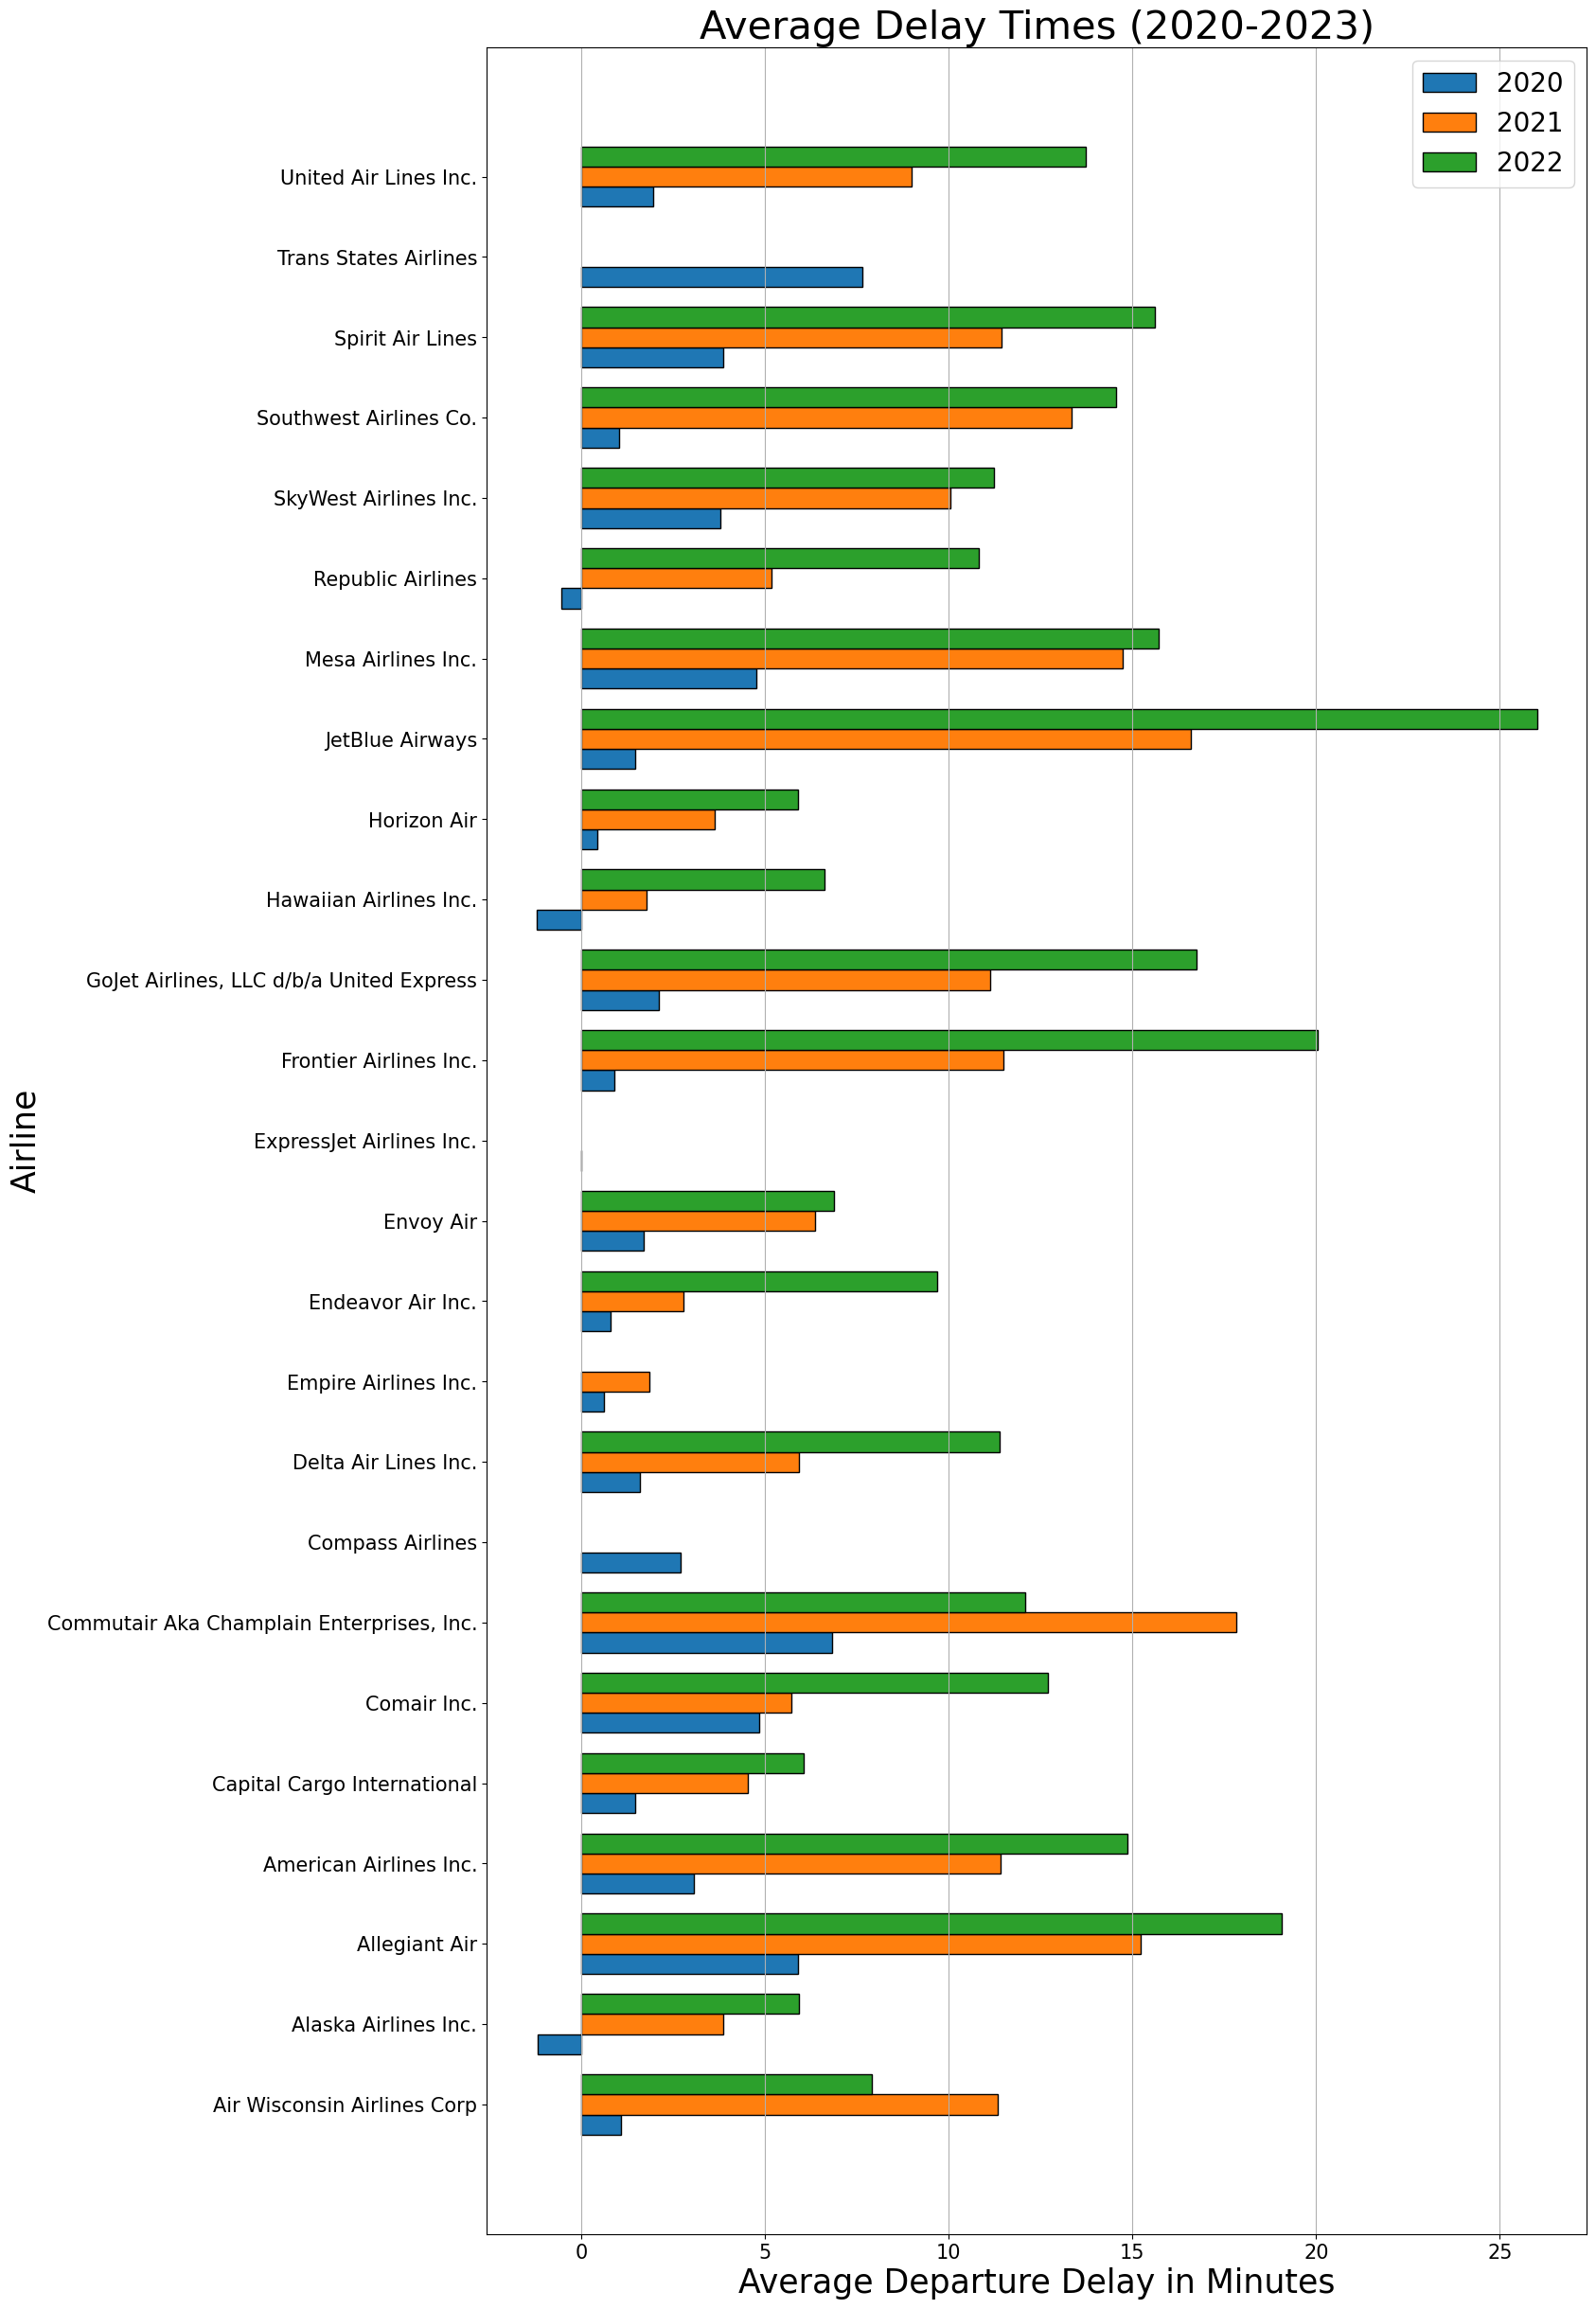

In [5]:
# creating a horiztonal bar graph showing the average delay times over the years

y = np.arange(len(df_flightdata_depdelay.index))
height = 0.25

plt.figure(figsize=(15, 30))

plt.barh(y - height, df_flightdata_depdelay[2020], height=height, label="2020", edgecolor="black")
plt.barh(y, df_flightdata_depdelay[2021], height=height, label="2021", edgecolor="black")
plt.barh(y + height, df_flightdata_depdelay[2022], height=height, label="2022", edgecolor="black")

plt.yticks(y, df_flightdata_depdelay.index)

plt.title("Average Delay Times (2020-2023)", fontsize=30)
plt.xlabel("Average Departure Delay in Minutes", fontsize=25)
plt.ylabel("Airline", fontsize=25)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.legend(fontsize=20)
plt.grid(axis="x")

plt.show()

Here is a static, horizontal bar graph showing each airlines average delay times per year. The blue, orange, and green bars represent the averages in 2020, 2021, and 2022 respectively. 

Some airlines have incomplete data across certain years, such as Trans States Airlines in 2021 and 2022, which may be due to missing or insufficient flight records. In addition, ExpressJet Airlines Inc. shows missing as well extremely low values in 2020, which is why the values in 2020 are barely visible.

There is a general pattern that average delay times in 2020 were less than those in 2021 and 2022. This suggests an overall incease increase in delays over the years likely due to increased flights following inital restricitions in travel due to COVID-19.


In [6]:
df_modified_depdelay = df_flightdata_depdelay.reset_index()
df_modified_depdelay

Year,Airline,2020,2021,2022
0,Air Wisconsin Airlines Corp,1.081872,11.335232,7.913244
1,Alaska Airlines Inc.,-1.181085,3.855417,5.925950
2,Allegiant Air,5.907016,15.222554,19.061569
3,American Airlines Inc.,3.062314,11.408765,14.876556
4,Capital Cargo International,1.464145,4.526329,6.044430
5,Comair Inc.,4.843367,5.727404,12.693968
6,"Commutair Aka Champlain Enterprises, Inc.",6.838677,17.817486,12.093640
7,Compass Airlines,2.698325,NaN,NaN
8,Delta Air Lines Inc.,1.588046,5.939530,11.398599
9,Empire Airlines Inc.,0.619188,1.848214,NaN


In [7]:
fig = px.bar(df_modified_depdelay, y="Airline", x = [2020, 2021, 2022], barmode="group", orientation = "h", height = 1500, 
            color_discrete_sequence=["blue", "orangered", "green"])
fig.update_traces(marker_line_color="black", marker_line_width=1)
fig.update_layout(title="Average Airline Departure Delays", xaxis_title = "Average Delay in Minutes", yaxis_title = "Airline",
                 title_font_size = 30, font_size = 16)
fig.show()

This is an interactive bar graph showing each airlines average departure delay in each year. Hovering over a bar with a cursor shows the exact stats per year per airline. For example we can see the in 2022, JetBlue airways had the longest average delay times of about 26 minutes. Contrarily, Hawaiian Airlines Inc had the shortest average delay time at about -1.21 minutes, with Alaska Airlines Inc close at about -1.18 minutes.

In [8]:
df_flightdata["DepStatus"].value_counts()

DepStatus
Early               9672919
On-Time             2838897
Delayed             1573189
Severely Delayed     798990
Unknown              528591
Name: count, dtype: int64

In [9]:
df_flightdata["Cancelled"].value_counts()

Cancelled
False    14877321
True       535265
Name: count, dtype: int64

In [10]:
df_flightdata["Diverted"].value_counts()

Diverted
False    15378983
True        33603
Name: count, dtype: int64

Text(0.5, 1.0, 'Diverted Status')

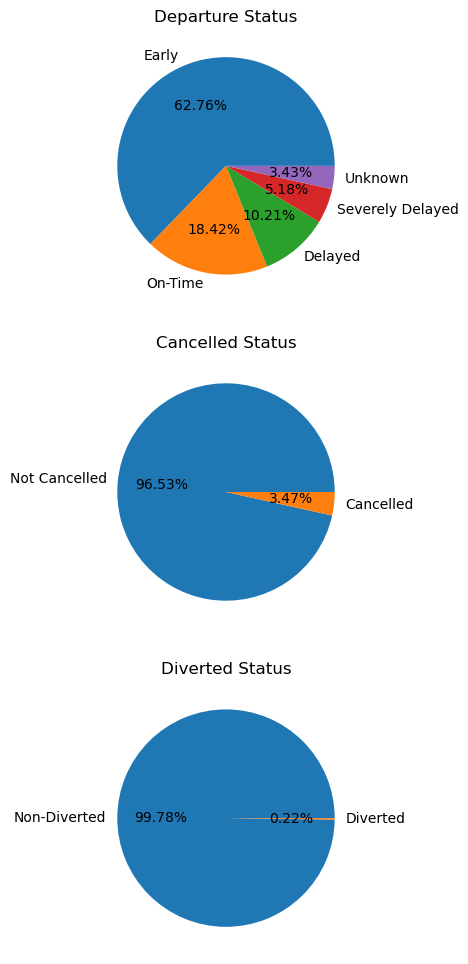

In [11]:
# Creating a subplot that contains pie charts which include information on departure, cancellation, and diverted statuses.

dep = df_flightdata["DepStatus"].value_counts()
cancel = df_flightdata["Cancelled"].value_counts()
div = df_flightdata["Diverted"].value_counts()

figure, axes = plt.subplots(3,1, figsize=(8,12))
axes[0].pie(np.array(dep), labels = dep.index, autopct = "%1.2f%%")
axes[0].set_title("Departure Status")
axes[1].pie(np.array(cancel), labels = ["Not Cancelled", "Cancelled"], autopct = "%1.2f%%")
axes[1].set_title("Cancelled Status")
axes[2].pie(np.array(div), labels = ["Non-Diverted", "Diverted"], autopct = "%1.2f%%")
axes[2].set_title("Diverted Status")

The subplot above contains 3 pie charts.

The Departure Status pie chart shows that a 62.76% of flights departed early. This may be due to schedule padding, early pushback reporting, or how departure delay is defined in the dataset. The category "Unknown" which is 3.43% may be attributed to missing flight data, or flights that were cancelled and never departed.

The Cancelled Status pie chart shows that 3.47% of flights were cancelled, which may make for a majority of the "Unknown" category seen in the Departue Status pie chart. 

The Diverted Status pie chart shows that 0.22% of flights were diverted, which seems to be a reasonable number considering the high number of flight records in the dataset.

In [12]:
from plotly.subplots import make_subplots

fig = make_subplots(rows=3, cols=1,
    specs=[[{"type": "pie"}],
           [{"type": "pie"}],
           [{"type": "pie"}]],
    subplot_titles=("Departure Status", "Cancelled Status", "Diverted Status")
)

dep = df_flightdata["DepStatus"].value_counts()
cancel = df_flightdata["Cancelled"].value_counts()
div = df_flightdata["Diverted"].value_counts()

fig.add_trace(px.pie(names=dep.index, values=dep.values).data[0], row=1, col=1)
fig.add_trace(px.pie(names=["Not Cancelled", "Cancelled"], values=cancel.values).data[0], row=2, col=1)
fig.add_trace(px.pie(names=["Non-Diverted", "Diverted"], values=div.values).data[0], row=3, col=1)

fig.update_layout(height=900, title="Flight Status Breakdown")

fig.show()

Above is an interactive subplot containing multiple pie charts, similar to the static pie charts shown earlier. This allows for a more detailed breakdown of flight status categories. For example, 535,265 flights were cancelled, and 33,603 flights were diverted within this dataset.

In [13]:
airports = df_flightdata.groupby("Origin")["DepDelay"].mean().sort_values(ascending = False)
airports

Origin
PPG    98.240741
BIH    30.101399
HYA    25.656410
MMH    23.597990
ILG    22.955696
         ...    
OME    -5.171932
GST    -6.836910
SPN    -7.115922
UIN    -7.600000
SCC    -8.666667
Name: DepDelay, Length: 384, dtype: float64

Pago Pago International Airport (PPG) had the highest average delay times.

In [18]:
highdelayairport = df_flightdata[df_flightdata["Origin"] == "PPG"]
px.box(highdelayairport["DepDelay"], title = "Pago Pago International Airport Delay Times (2020-2022)")

This is an interactive box plot, which shows details on the airport with the highest average delays which is PPG, Pago Pago International Airport. 
The lowest delay in the dataset was -25 minutes, 25th percentitle was -6 minutes, median was 13.5 minutes, and the 75th percentitle was 51 minutes.
We can also notice that there are some outliers, for example delays of 267, 1037, 1483, and 1551 minutes.

In [15]:
ppgairport = df_flightdata[(df_flightdata["Origin"] == "PPG") & (df_flightdata["DepDelay"] <=250)]
ppgairport["DepDelay"].sort_values()

3782779     -25.0
12692172    -22.0
13905048    -17.0
1242210     -17.0
13905046    -16.0
13905043    -14.0
13905045    -13.0
3782784     -12.0
2794945     -12.0
3782778      -9.0
3782780      -7.0
1242209      -7.0
1242212      -7.0
1242213      -6.0
2794948      -5.0
12692176     -5.0
13905044     -4.0
3782777      -1.0
13450794     -1.0
2794946       1.0
12692178      2.0
2794952       3.0
3782783       3.0
2794950       4.0
11718827      5.0
12692179      8.0
2794951      13.0
11719538     14.0
1242211      15.0
12692174     16.0
11718826     16.0
13450795     19.0
2794947      21.0
12692177     34.0
14349473     38.0
14922114     40.0
12692173     41.0
13450796     41.0
2794953      43.0
1242214      45.0
1242216      51.0
6693028      59.0
13905047     60.0
7203787      62.0
10406034     64.0
14349474     76.0
14922115     76.0
5872828      81.0
12259672     91.0
7203788     125.0
Name: DepDelay, dtype: float64

In [16]:
print(ppgairport["DepDelay"].mean())

19.34


In [21]:
px.box(ppgairport["DepDelay"], title= "Pago Pago International Airport Delay Times (2020-2022) - Excluding Outliers")

This is an updated box plot, which has major outliers removed. Stats such as the median, 25th and 75th percentitle are close to their original values. However as calcuated in the previous cell, the average changed from 98.24 minutes to 19.34 minutes. 